In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, utils, models, layers, regularizers
import cv2

Ce bloc importe les bibliothèques essentielles pour ce projet. On utilise TensorFlow/Keras pour le deep learning, Matplotlib pour l'affichage, et NumPy pour les tableaux.

Chargement des données Fashion-MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()
print("Train :", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


Ce bloc charge le jeu de données Fashion MNIST, qui contient des images de vêtements en niveaux de gris. Les données sont séparées en ensembles d'entraînement et de test.

Prétraitement des images et des labels

In [ ]:
x_train = x_train.reshape(-1, 28 * 28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype('float32') / 255.0
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)
print("Après prétraitement :", x_train.shape, y_train.shape)

Après prétraitement : (60000, 784) (60000, 10)


Ce bloc normalise les pixels des images entre 0 et 1 en divisant par 255. Cela aide le modèle à mieux converger pendant l’entraînement.

Définition de l'architecture CNN (LeNet-5 avec padding et régularisation ajustée)

In [ ]:
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(84, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ce bloc définit le modèle de réseau de neurones convolutionnel (CNN). Il contient des couches de convolution, de regroupement (max pooling), de normalisation, et de classification finale.

 Compilation du modèle

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,542 (959.15 KB)

 Trainable params: 245,542 (959.15 KB)

 Non-trainable params: 0 (0.00 B)

Ce bloc compile le modèle en spécifiant la fonction de perte (entropie croisée), l’optimiseur (Adam), et la métrique à suivre (exactitude).

Entraînement

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=45,
    validation_split=0.1,
    verbose=2
)

Epoch 1/15
1200/1200 - 12s - 10ms/step - accuracy: 0.7886 - loss: 0.9054 - val_accuracy: 0.8403 - val_loss: 0.6461
Epoch 2/15
1200/1200 - 9s - 8ms/step - accuracy: 0.8365 - loss: 0.6404 - val_accuracy: 0.8470 - val_loss: 0.5715
Epoch 3/15
1200/1200 - 14s - 11ms/step - accuracy: 0.8402 - loss: 0.5889 - val_accuracy: 0.8463 - val_loss: 0.5548
Epoch 4/15
1200/1200 - 17s - 14ms/step - accuracy: 0.8438 - loss: 0.5628 - val_accuracy: 0.8562 - val_loss: 0.5226
Epoch 5/15
1200/1200 - 19s - 16ms/step - accuracy: 0.8469 - loss: 0.5464 - val_accuracy: 0.8505 - val_loss: 0.5074
Epoch 6/15
1200/1200 - 10s - 8ms/step - accuracy: 0.8486 - loss: 0.5408 - val_accuracy: 0.8470 - val_loss: 0.5278
Epoch 7/15
1200/1200 - 10s - 8ms/step - accuracy: 0.8499 - loss: 0.5356 - val_accuracy: 0.8427 - val_loss: 0.5284
Epoch 8/15
1200/1200 - 10s - 8ms/step - accuracy: 0.8523 - loss: 0.5258 - val_accuracy: 0.8653 - val_loss: 0.4888
Epoch 9/15
1200/1200 - 11s - 9ms/step - accuracy: 0.8520 - loss: 0.5226 - val_accurac

Ce bloc entraîne le modèle sur les données d'entraînement pendant un certain nombre d'époques. Il permet au réseau d'apprendre à reconnaître les vêtements à partir d'exemples étiquetés.

Tracé des courbes de précision

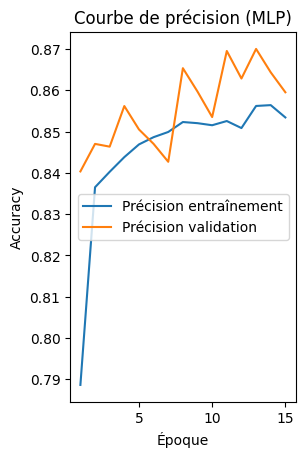

In [ ]:
epochs = range(1, len(history.history['accuracy']) + 1)
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Précision entraînement')
plt.plot(epochs, history.history['val_accuracy'], label='Précision validation')
plt.title('Courbe de précision (MLP)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('fashion_mnist_accuracy_curve_mlp.png')
plt.show()

Ce bloc charge le jeu de données Fashion MNIST, qui contient des images de vêtements en niveaux de gris. Les données sont séparées en ensembles d'entraînement et de test.

Évaluation sur le jeu de test

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Précision sur test (Fashion-MNIST avec MLP): {test_acc*100:.2f}%")

Précision sur test (Fashion-MNIST avec MLP): 85.01%


Ce bloc évalue la performance du modèle sur les données de test pour vérifier s’il a bien généralisé.

Visualisation de quelques prédictions avec images très claires

In [ ]:
indices = np.random.choice(len(x_test), 10, replace=False)
x_sample = x_test[indices]
y_true = np.argmax(y_test[indices], axis=1)

Prédiction optimisée pour éviter le retracing

In [ ]:
y_probs = model.predict(x_sample, batch_size=10)
y_pred = np.argmax(y_probs, axis=1)
confidences = np.max(y_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


Ce bloc utilise le modèle entraîné pour prédire les classes des images de test. Cela permet de vérifier la capacité du modèle à classifier de nouvelles images.

Dictionnaire de correspondance des classes avec des noms raccourcis

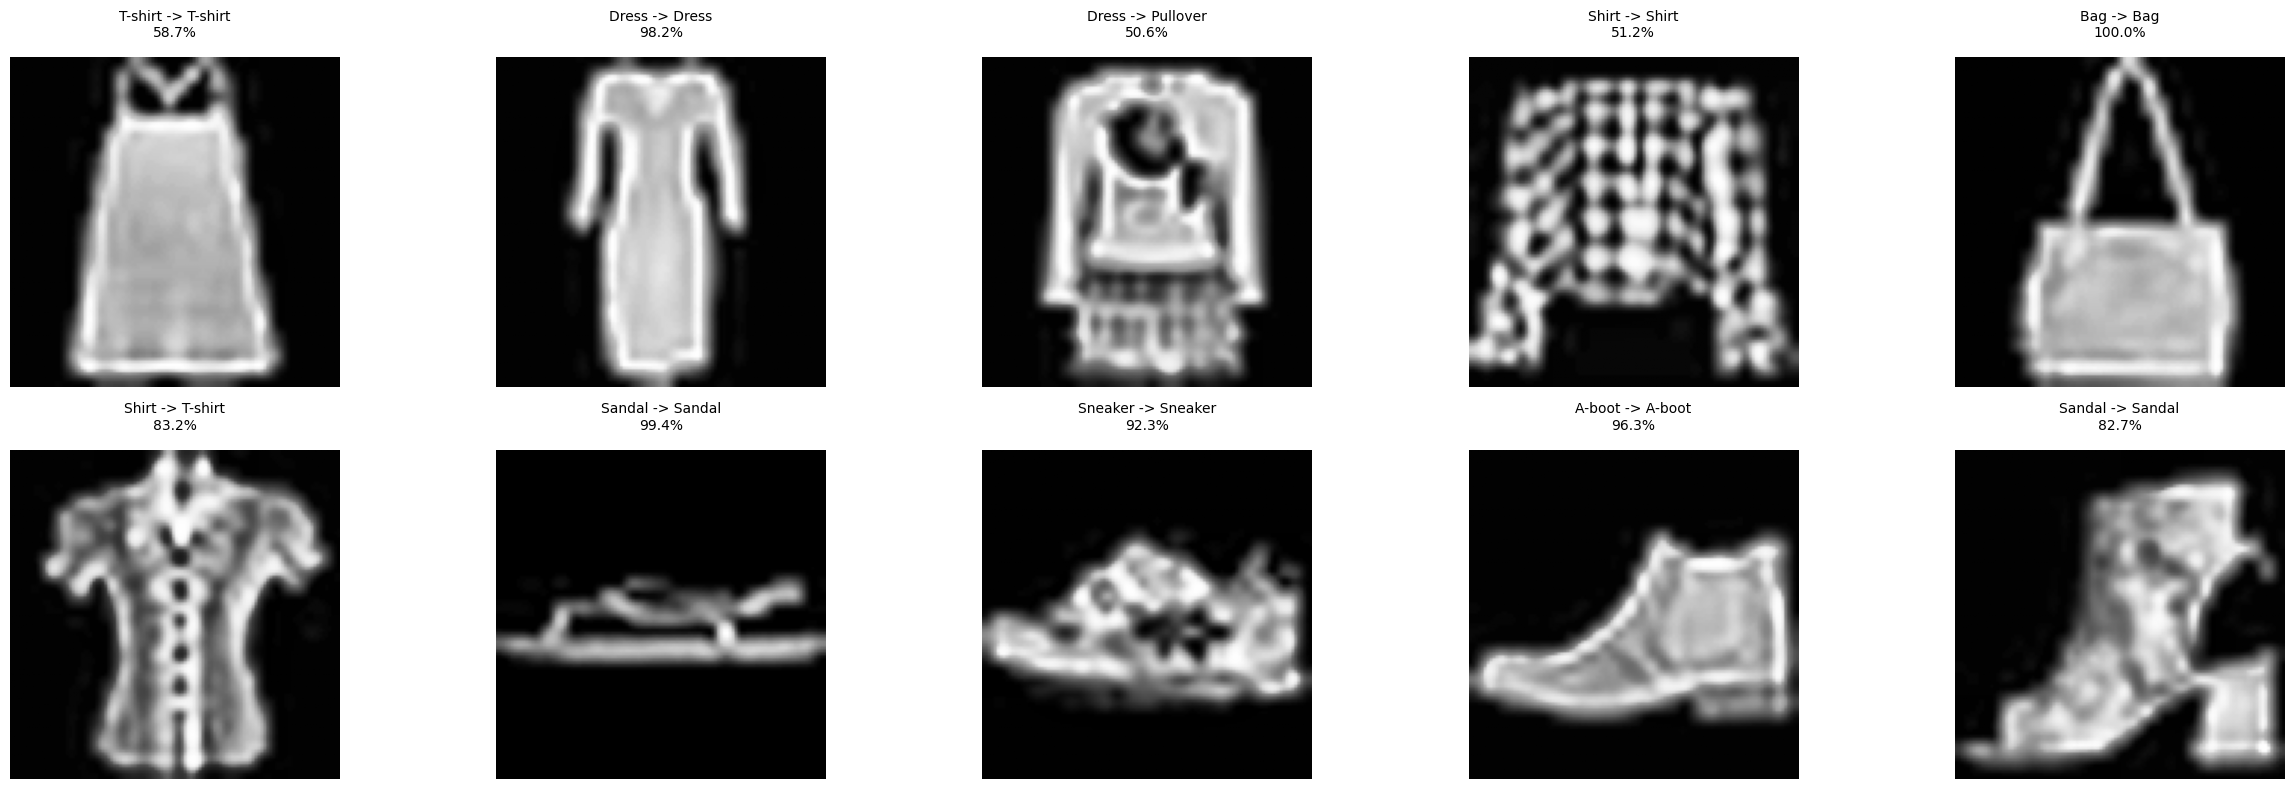

In [ ]:
class_names = {
    0: 'T-shirt',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'A-boot'
}

plt.figure(figsize=(25, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = x_sample[i].reshape(28, 28)
    img = (img * 255).astype(np.uint8)
    img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_CUBIC)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    img = clahe.apply(img)
    plt.imshow(img, cmap='gray')
    pct = confidences[i] * 100
    true_name = class_names[y_true[i]]
    pred_name = class_names[y_pred[i]]
    plt.title(f"{true_name} -> {pred_name}\n{pct:.1f}%", fontsize=10, pad=15)
    plt.axis('off')
plt.tight_layout()
plt.savefig('fashion_mnist_predictions_mlp.png', dpi=300)
plt.show()
plt.close()

Ce bloc charge le jeu de données Fashion MNIST, qui contient des images de vêtements en niveaux de gris. Les données sont séparées en ensembles d'entraînement et de test.